# CNNs & convolution — a step-by-step, runnable notebook

A fully-connected layer on a real image is hopeless: a 224×224×3 image into one 1000-unit dense layer is **150 million weights in a single layer**, and it must re-learn a cat in every position. A **convolution** fixes both problems with one idea — slide a small **filter** across the image looking for a local pattern, and **share that filter's weights everywhere**. That buys locality, an ~8-order-of-magnitude parameter cut (independent of image size), and translation **equivariance**.

This notebook builds 2-D convolution from scratch in NumPy and proves it correct on **real** data: the forward pass matches im2col, `scipy.signal`, and `torch` to machine tolerance; the **backward** pass is gradient-checked *and* cross-checked against `torch.autograd`; max-pooling routes its gradient to the argmax exactly as torch does; a real Sobel filter on a real photo reproduces `scipy`; and a small CNN, trained on scikit-learn digits, matches a 5× larger MLP's accuracy while being far more robust to a 1-pixel shift. Every cell uses the **exact same functions** as the chapter and its figures (imported from `cnn.py`), so the numbers here are the numbers there.

> Companion page: **CNNs & Convolution**. Run top-to-bottom (Kernel → Restart & Run All); it is CPU-only, seeded, and finishes in a few seconds.

## Step 0 — Setup: import the real module and print versions

We import the from-scratch functions from the chapter module so this notebook runs the *same code* the page and figures use, and print the library versions the results were produced on.

In [1]:
import numpy as np
import scipy
import torch
import sklearn
import matplotlib.pyplot as plt

from cnn import (
    worked_hand_conv, verify_forward, output_size, param_economics, verify_backward, verify_pool,
    measure_equivariance, sobel_edges, load_sample_gray, receptive_field_growth, train_cnn_vs_mlp,
)

np.random.seed(0)
torch.manual_seed(0)
print(f'numpy {np.__version__} | scipy {scipy.__version__} | torch {torch.__version__} | scikit-learn {sklearn.__version__}  (CPU)')

numpy 2.4.6 | scipy 1.17.1 | torch 2.12.0 | scikit-learn 1.9.0  (CPU)


## Step 1 — One convolution, fully by hand

A convolution lays a small **kernel** over a patch of the input, multiplies element-wise, and **sums** the products into a *single* output number — one dot product. Take the top-left 3×3 patch of a 5×5 input and a vertical-edge kernel $\begin{bmatrix}1&0&-1\\1&0&-1\\1&0&-1\end{bmatrix}$:

$$(2\cdot1+0\cdot0+0\cdot{-}1) + (2\cdot1+1\cdot0+0\cdot{-}1) + (2\cdot1+2\cdot0+2\cdot{-}1) = 2+2+0 = 4.$$

That 4 is the top-left cell of the feature map. Slide the kernel across every valid position for the rest.

In [2]:
hc = worked_hand_conv()
print('patch =\n', hc.patch.astype(int))
print('kernel =\n', hc.kernel.astype(int))
print(f'top-left output value = {hc.top_left:.0f}')
print('full 3x3 feature map =\n', hc.feature_map)

patch =
 [[2 0 0]
 [2 1 0]
 [2 2 2]]
kernel =
 [[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]
top-left output value = 4
full 3x3 feature map =
 [[ 4. -1. -3.]
 [ 0.  0.  2.]
 [-4. -1.  4.]]


## Step 2 — 2-D convolution from scratch, verified four ways

The operation deep learning calls 'convolution' is really **cross-correlation** (no kernel flip) — $Y[i,j]=\sum_{u,v} X[i+u,j+v]\,K[u,v]$. We implement it three ways and check them against a fourth:

- **`conv2d_naive`** — explicit multiply-and-sum loops;
- **`conv2d_im2col`** — unfold every patch into a column, then one big matmul (**what frameworks do**);
- **`scipy.signal.correlate2d`** — an independent signal-processing engine (single-channel case);
- **`torch.nn.functional.conv2d`** — the reference.

All four agree: the loops match torch to summation-order noise, im2col matches it *exactly* (it **is** the same matmul), and scipy matches the single-channel case. Each equality is a hard `assert` in the module.

In [3]:
fc = verify_forward()
print(f'output shape            : {fc.out_shape}')
print(f'max|naive  - torch|     : {fc.naive_vs_torch:.2e}   (float64 summation order)')
print(f'max|im2col - torch|     : {fc.im2col_vs_torch:.2e}   (im2col IS the same matmul)')
print(f'max|scipy  - naive|     : {fc.scipy_vs_naive:.2e}')
print('OK: loops == im2col == scipy == torch')

output shape            : (2, 5, 5, 5)
max|naive  - torch|     : 7.11e-15   (float64 summation order)
max|im2col - torch|     : 3.55e-15   (im2col IS the same matmul)
max|scipy  - naive|     : 4.44e-16
OK: loops == im2col == scipy == torch


## Step 3 — The output-size formula

Three knobs set the output dimensions: kernel size $K$, stride $S$, padding $P$. For input width $W$:

$$O = \left\lfloor \frac{W - K + 2P}{S} \right\rfloor + 1.$$

Padding widens the input to $W+2P$; a $K$-wide kernel starts anywhere in the span $W+2P-K$, stepped by $S$ (the floor drops a partial final step); $+1$ for the first position. Two patterns recur: **'same'** padding $P=(K-1)/2$ at stride 1 preserves size (why VGG stacks 3×3s), and **stride 2** roughly halves it.

In [4]:
print(f"{'W':>4}{'K':>4}{'P':>4}{'S':>4}{'O':>5}   note")
cases = [(7,3,0,1,'valid: shrinks by K-1'), (7,3,1,1,'same: size preserved'),
         (7,3,0,2,'stride 2: ~halves'), (224,11,2,4,'AlexNet conv1 -> 55'),
         (224,3,1,1,'VGG 3x3 same -> 224')]
for W,K,P,S,note in cases:
    print(f'{W:>4}{K:>4}{P:>4}{S:>4}{output_size(W,K,P,S):>5}   {note}')

   W   K   P   S    O   note
   7   3   0   1    5   valid: shrinks by K-1
   7   3   1   1    7   same: size preserved
   7   3   0   2    3   stride 2: ~halves
 224  11   2   4   55   AlexNet conv1 -> 55
 224   3   1   1  224   VGG 3x3 same -> 224


## Step 4 — Parameters and FLOPs: the weight-sharing economics

A conv layer has $C_{out}(C_{in}K^2)+C_{out}$ parameters — **independent of image size**. A 3×3, 3→64 conv is 1,792 weights whether the image is 32×32 or 4K. The equivalent dense layer over a 224×224 image (every input pixel wired to every output pixel) needs ~$4.8\times10^{11}$ — the conv is **~270 million times smaller**. FLOPs, though, scale with the spatial size ($\text{MACs}=C_{out}H'W'(C_{in}K^2)$): convs are *cheap to store but expensive to run on big images*. Depthwise-separable conv factors the cost by $1/C_{out}+1/K^2$ (~8.4× for a 3×3).

In [5]:
pe = param_economics(cin=3, cout=64, k=3, img=224)
print(f'3x3 conv 3->64      : {pe.conv_params:,} params')
print(f'equivalent dense    : {pe.dense_params:,} params')
print(f'ratio               : ~{pe.ratio:,.0f}x smaller  (and size-independent)')
print(f'conv MACs (224x224) : {pe.conv_macs:,}  (~{pe.conv_gflop:.2f} GFLOP)')
print(f'depthwise-separable : {pe.sep_standard:,} -> {pe.sep_separable:,} = {pe.sep_ratio:.2f}x  (theory {1/pe.sep_theory:.2f}x)')

3x3 conv 3->64      : 1,792 params
equivalent dense    : 483,385,147,392 params
ratio               : ~269,746,176x smaller  (and size-independent)
conv MACs (224x224) : 86,704,128  (~0.17 GFLOP)
depthwise-separable : 73,728 -> 8,768 = 8.41x  (theory 8.41x)


## Step 5 — The backward pass: gradient-checked AND autograd-checked

Convolution is linear, so it slots into [backprop](../../02-Backpropagation-and-Computational-Graphs/02-Backpropagation-and-Computational-Graphs.md) like any layer — and all three gradients are themselves convolutions. `conv2d_backward` returns $\partial L/\partial X$, $\partial L/\partial W$ (a cross-correlation of the input with the upstream gradient — the shared kernel's gradient *accumulates* over every position, the signature of weight sharing), and $\partial L/\partial b$ (a spatial sum). We prove it two independent ways: a **centred finite-difference** check on every kernel entry (median rel error ~1e-9), and a **torch autograd** cross-check on the identical op (~1e-15). Both are hard `assert`s.

In [6]:
bc = verify_backward()
print(f'kernel entries checked        : {bc.n_params}')
print(f'dW rel error  median / max    : {bc.median_rel_error_dw:.2e} / {bc.max_rel_error_dw:.2e}  (<< 1e-4 => correct)')
print(f'vs torch autograd  dX / dW / db : {bc.dx_vs_torch:.1e} / {bc.dw_vs_torch:.1e} / {bc.db_vs_torch:.1e}')
print('OK: from-scratch conv backward matches finite differences AND torch autograd')

kernel entries checked        : 54
dW rel error  median / max    : 4.61e-11 / 8.01e-10  (<< 1e-4 => correct)
vs torch autograd  dX / dW / db : 3.6e-15 / 2.7e-15 / 1.8e-15
OK: from-scratch conv backward matches finite differences AND torch autograd


## Step 6 — Max-pooling: forward and backward

Pooling shrinks a feature map by summarizing each window into one number — **max-pool** keeps the strongest activation. It has **no parameters**. Its backward pass is clean: route the whole upstream gradient to the single position that *won* the max (remembered via the argmax), zero to the rest. We cross-check both forward and backward against torch — they agree exactly.

In [7]:
pc = verify_pool()
print(f'pooled output shape       : {pc.out_shape}')
print(f'forward  max|ours - torch|: {pc.fwd_vs_torch:.1e}')
print(f'backward max|ours - torch|: {pc.bwd_vs_torch:.1e}   (gradient routed to the argmax)')
print('OK: from-scratch max-pool matches torch forward and backward')

pooled output shape       : (2, 3, 3, 3)
forward  max|ours - torch|: 0.0e+00
backward max|ours - torch|: 0.0e+00   (gradient routed to the argmax)
OK: from-scratch max-pool matches torch forward and backward


## Step 7 — Translation equivariance, measured

The deep consequence of weight sharing: **shift the input, and the feature map shifts the same way** — $\mathrm{Conv}(T(x)) = T(\mathrm{Conv}(x))$. The detector fires wherever the feature goes, *without* relearning. This is exactly the property a dense net lacks. We verify it directly: convolve a small pattern, then convolve a 1-pixel-shifted copy, and confirm the outputs are shifts of each other.

In [8]:
eq = measure_equivariance()
print(f'max |shift(Conv(x)) - Conv(shift(x))| (interior) = {eq.max_diff:.2e}')
print('OK: convolution is translation-equivariant (shift in -> shift out)')

max |shift(Conv(x)) - Conv(shift(x))| (interior) = 0.00e+00
OK: convolution is translation-equivariant (shift in -> shift out)


## Step 8 — A real filter on a real image: Sobel edges

A kernel *is* a learned pattern detector. Before learned kernels, the classic **Sobel** edge filter was hand-designed — and it is exactly the kind of vertical/horizontal-edge detector a CNN's *first* layer reliably learns on its own. We apply it with our own `conv2d_naive` to a real grayscale photograph (bundled with scikit-learn, no download) and verify against `scipy`. Flat regions vanish to black; edges light up.

image shape (427, 640)   our-conv vs scipy = 2.27e-13


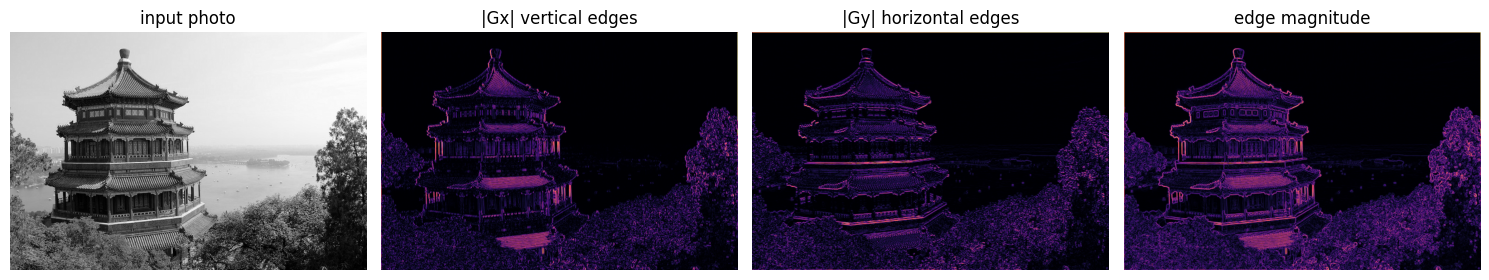

In [9]:
sob = sobel_edges(load_sample_gray())
print(f'image shape {sob.gray.shape}   our-conv vs scipy = {sob.ours_vs_scipy:.2e}')
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
panels = [(sob.gray, 'input photo', 'gray'), (sob.gx, '|Gx| vertical edges', 'magma'),
          (sob.gy, '|Gy| horizontal edges', 'magma'), (sob.magnitude, 'edge magnitude', 'magma')]
for ax, (img, title, cmap) in zip(axes, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 9 — Receptive-field growth with depth

The **receptive field** is the region of the input a neuron can see. For stacked $K\times K$ convs at stride 1 it grows *linearly*: $\text{RF}_L = 1 + L(K-1)$. For $K=3$ that's $3,5,7,9,\dots$ — which is why **two stacked 3×3 convs have the same 5×5 receptive field** as one 5×5 conv, with fewer weights and an extra nonlinearity (the VGG insight). A stride-2 pool multiplies the *jump* between neurons, so the RF then grows *multiplicatively* — a conv after the pool adds 4, not 2.

In [10]:
rf = receptive_field_growth(k=3, depth=6)
print('stacked 3x3, stride 1:  layers', rf.layers, '-> RF', rf.rf_stride1)
print('\nwith a stride-2 pool in the middle (name, jump, RF):')
for name, j, r in rf.rf_with_pool:
    print(f'  {name:<14} jump={j}  RF={r}')

stacked 3x3, stride 1:  layers [1, 2, 3, 4, 5, 6] -> RF [3, 5, 7, 9, 11, 13]

with a stride-2 pool in the middle (name, jump, RF):
  input          jump=1  RF=1
  conv 3x3 s1    jump=1  RF=3
  pool 2x2 s2    jump=2  RF=4
  conv 3x3 s1    jump=2  RF=8


## Step 10 — The payoff: a CNN vs a bigger MLP on real digits

Now train a small **CNN** (conv→pool→conv→pool→FC) and a deliberately *larger* fully-connected **MLP** on the scikit-learn digits (8×8 images, 10 classes). The CNN matches the MLP's clean accuracy with **~5× fewer parameters** — the weight-sharing win. And when we shift every test digit by one pixel, the CNN holds up far better than the position-sensitive MLP: equivariance, paying off on data it never saw shifted.

In [11]:
tr = train_cnn_vs_mlp(epochs=30)
print(f'CNN : {tr.cnn_params:,} params   clean acc = {tr.cnn_acc*100:.1f}%   shifted-1px acc = {tr.cnn_acc_shift*100:.1f}%')
print(f'MLP : {tr.mlp_params:,} params   clean acc = {tr.mlp_acc*100:.1f}%   shifted-1px acc = {tr.mlp_acc_shift*100:.1f}%')
print(f'-> CNN uses {tr.mlp_params/tr.cnn_params:.1f}x FEWER params, matches clean accuracy,')
print(f'   and is far more shift-robust ({tr.cnn_acc_shift*100:.0f}% vs {tr.mlp_acc_shift*100:.0f}%)')

CNN : 1,898 params   clean acc = 97.6%   shifted-1px acc = 60.6%
MLP : 9,610 params   clean acc = 98.0%   shifted-1px acc = 46.2%
-> CNN uses 5.1x FEWER params, matches clean accuracy,
   and is far more shift-robust (61% vs 46%)


## Step 11 — What the CNN learned: first-layer filters and feature maps

Finally, *see* what gradient descent found. The trained CNN's 8 first-layer 3×3 kernels are local pattern detectors (edges and strokes — strikingly Sobel-like, just as Step 8 foreshadowed), and each produces a **feature map** highlighting where its pattern occurs in a real test digit.

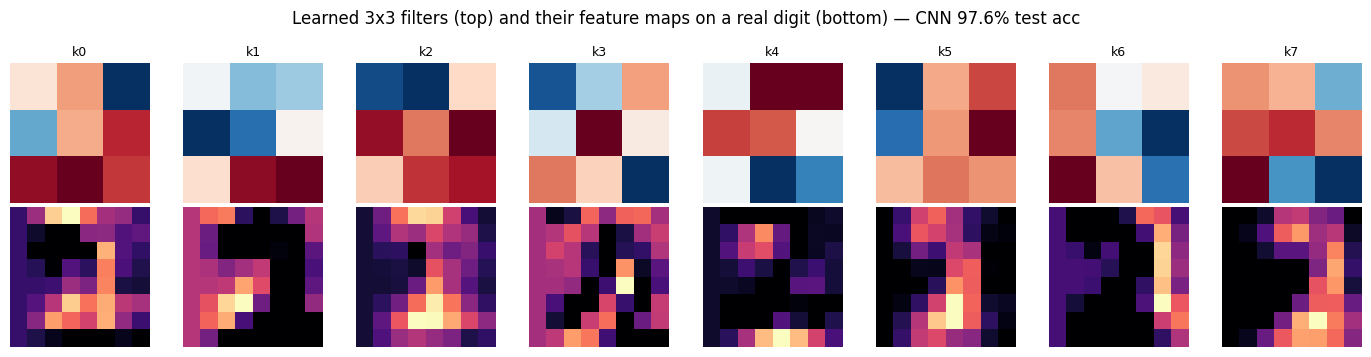

In [12]:
fig, axes = plt.subplots(2, 8, figsize=(14, 3.6))
for i in range(8):
    axes[0, i].imshow(tr.first_filters[i], cmap='RdBu_r')
    axes[0, i].set_title(f'k{i}', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(tr.feature_maps[i], cmap='magma')
    axes[1, i].axis('off')
fig.suptitle(f'Learned 3x3 filters (top) and their feature maps on a real digit (bottom) — CNN {tr.cnn_acc*100:.1f}% test acc')
plt.tight_layout()
plt.show()

## Recap

A CNN slides small **learned filters** over the input and **shares those weights** across every position — encoding **locality**, **weight-sharing**, and **translation-equivariance**, exactly the structure images have. We built 2-D convolution from scratch and proved it correct against im2col, scipy, and torch (forward); against finite differences and torch autograd (backward); measured its equivariance; applied a real Sobel filter to a real photo; and trained a CNN that matched a 5× larger MLP with far more shift robustness. Output size is $O = \lfloor(W-K+2P)/S\rfloor + 1$; params are $C_{out}(C_{in}K^2)+C_{out}$ (size-independent); the conv backward pass is itself a (transposed) convolution; and pooling routes its gradient to the argmax.

See the companion page for the full derivations, the im2col/Toeplitz view, 1×1 and depthwise-separable convolutions, the LeNet→ResNet lineage, the CNN-vs-ViT trade, pitfalls, and references.